![Regression line](https://media.geeksforgeeks.org/wp-content/uploads/20251212171555234007/introduction_to_linear_reg.webp)


# Import Required Libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
df = pd.read_csv(r"data/HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


# Load and Explore the Dataset


In [17]:
# Display the first few rows of the dataset
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX  ...  TAX  PTRATIO       B  LSTAT  MEDV
0  0.00632  18.0   2.31   0.0  0.538  ...  296     15.3  396.90   4.98  24.0
1  0.02731   0.0   7.07   0.0  0.469  ...  242     17.8  396.90   9.14  21.6
2  0.02729   0.0   7.07   0.0  0.469  ...  242     17.8  392.83   4.03  34.7
3  0.03237   0.0   2.18   0.0  0.458  ...  222     18.7  394.63   2.94  33.4
4  0.06905   0.0   2.18   0.0  0.458  ...  222     18.7  396.90    NaN  36.2

[5 rows x 14 columns]


In [18]:
# Check for missing values
print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In this dataset:

- **_CRIM_**: per capita crime rate by town
- **_ZN_**: proportion of residential land zoned for lots over 25,000 sq. ft.
- **_RM_**: average number of rooms per dwelling
- **_PRICE_**: median value of owner-occupied homes in $1000s (this is our target variable)


# Selecting Features and Splitting the Data


In [13]:
# Define the feature (independent variable) and target (dependent variable)
X = df[["RM"]]  # Number of rooms
y = df["MEDV"]  # House prices

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 404
Testing set size: 102


# Train the Simple Linear Regression Model


In [21]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Print the intercept and coefficient
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_}")

Intercept: -36.24631889813792
Coefficient: [9.34830141]


# Make Predictions


In [23]:
# Predict house prices for the test set
y_pred = model.predict(X_test)

# Display the first few predictions alongside the actual values
predictions = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(predictions.head())

     Actual  Predicted
173    23.6  23.732383
274    32.4  26.929502
491    13.6  19.684568
72     22.8  20.451129
452    16.1  22.619935


# Visualize the Regression Line


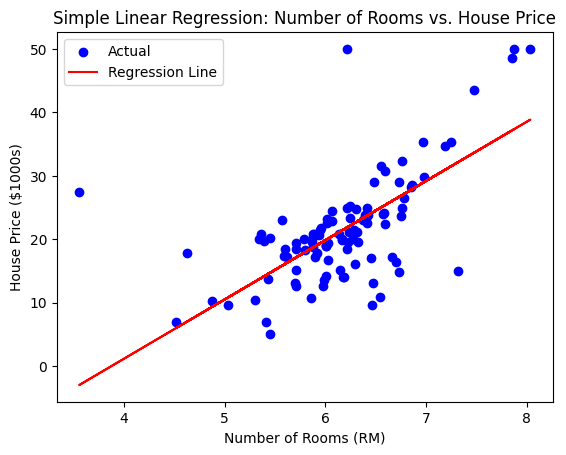

In [27]:
# Plot the actual data points
plt.scatter(X_test, y_test, color="blue", label="Actual")

# Plot the regression line
plt.plot(X_test, y_pred, color="red", label="Regression Line")

# Add labels and title
plt.xlabel("Number of Rooms (RM)")
plt.ylabel("House Price ($1000s)")
plt.title("Simple Linear Regression: Number of Rooms vs. House Price")
plt.legend()
plt.show()

# Evaluate the Model


In [32]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f"R-squared score: {r2}")

Mean Squared Error: 46.144775347317264
R-squared score: 0.3707569232254778
